::: {.hidden}
$$
\gdef\rvar#1{\mathrm{#1}}
\gdef\rvec#1{\mathbf{#1}}
\gdef\vec#1{\boldsymbol{#1}}
\gdef\tens#1{\boldsymbol{\mathsf{#1}}}
\gdef\tensel#1{\mathsf{#1}}
\gdef\st#1{\mathcal{#1}}
\gdef\diag#1{\mathrm{diag}(\vec{#1})}
$$
:::

In [2]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/01_Introduction
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

import matplotlib.image as mpimg

def std_full(T):
    means = T.mean(dim=0, keepdim=True)
    stds = T.std(dim=0, keepdim=True)
    return ((T - means) / stds), means, stds

def standardize(T):
    return std_full(T)[0]

def std_inverse(T, means, stds):
    k = T.size()[1]
    return T*stds[:,:k] + means[:,:k]

def normalize(T):
    Tv = T.view(T.size(0), -1)
    Tv -= Tv.min()
    Tv /= Tv.max()
    return Tv

def to_coefficients(T):
    return T / T.sum(0, keepdim=True)[0]

def plot_scores(x=0,y=0):
    ort = torch.tensor([[x], [y]], dtype=torch.float32 )
    colors=['green', 'orange']
    fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
    ax[0].set_ylabel(us.columns[1])

    for a in ax:
        a.set_xlabel(us.columns[0])
        a.scatter(X_us[:,0],X_us[:,1])
        l,r = a.get_xlim()
        b,t = a.get_ylim()
       

        x = np.linspace(l,r,20)
        y = (ort[1]/ort[0])*x 
        a.plot(x,y, c='orange')

    for i in range(len(X_us)):
        m =  np.dot(np.divide(np.dot(ort,ort.T), np.dot(ort.T,ort)), np.array([X_us[i,0],X_us[i,1]]).T)
        ax[1].plot([X_us[i,0],m[0]],[X_us[i,1],m[1]], c='green')
        ax[1].scatter(m[0], m[1], marker='x', c='k')

    fig.tight_layout()
    plt.show()

<IPython.core.display.Latex object>

# Linear algebra

- Since ancient times in Babylon and Egypt, mathematicians recognized that solution of many practical problems can be reduced to finding solutions of systems of equations
- Linear algebra is now widely used in various branches of theoretical and applied mathematics (see Strang for an introduction, Shilov for very precise definitions and proofs, and Petersen and Pedersen if you need to look up a formula) 


<div class="cite"> Strang, G.: Linear algebra and learning from data. Wellesley-Cambridge Press, 2019, ISBN 978-0-692-19638-0, pp. 1-432</div>
<div class="cite"> Shilov, G.E.: Linear Algebra. Revised English Edition (Trs. RA Silverman). Dover Publications, 1971, ISBN-13: 978-0-486-63518-7, pp 1-400</div>
<div class="cite"> Petersen K.B., Pedersen M.S.: The Matrix Cookbook. Technical University of Denmark. (http://www2.imm.dtu.dk/pubdb/edoc/imm3274.pdf)</div>

## Vectors

- Any *scalar* is just numbers of some kind, e.g. $x \in \mathbb{R}$ or $y \in \mathbb{N}$
- A *vector* is a 1-D array (list) of numbers, which order is fixed (in opposite to a set), e.g., $\vec{x} \in \mathbb{R}^n$ or $\vec{y} \in \mathbb{N}^n$
  - $\mathbb{R}^n$ is an $n$ times Cartesian product of elements in $\mathbb{R}$, i.e., $\mathbb{R}\times\dots\times\mathbb{R}$ 
  - Vectors considered hereafter are columns
$$ \vec{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$$
   where $x_1$ is the first element, $x_2$ - the second, and so forth
   - Every element of a vector gives coordinates of a point along the corresponding axis
   - Selection of vector elements can be defined by a set of indices
   - Exclusion of the elements is done in the same way using negative subscripts
   - For instance, e.g., given $S=\{1,3,4\}$
   $$ \vec{x}_S = \begin{bmatrix} x_1 \\ x_3 \\ x_4 \end{bmatrix}  \quad ~~~~ \vec{x}_{-S} = \begin{bmatrix} x_2 \\ x_5 \\ \vdots \\ x_n \end{bmatrix}$$


Plotting tensor with dim: 2 and shape: torch.Size([2, 1])


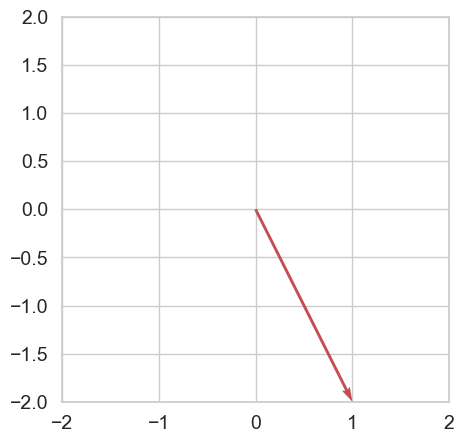

In [3]:
plot2d(torch.tensor([[1],[-2]]))

- Scalers are called so since multiplication of a vector by a number only *scales the vector*

In [4]:
t = torch.tensor([[1],[-2]])
@interact(x=(-2,2,1))
def scale(x=1): 
    if x!=0: 
        plot2d(torch.cat((t,t.mul(x)),1))
    else:  
        plot2d(t)
    plt.show()

interactive(children=(IntSlider(value=1, description='x', max=2, min=-2), Output()), _dom_classes=('widget-int…

- Transpose of a vector $\mathbf{x}$ yields a row vector
$$  \mathbf{x}^\top = [x_1, x_2, \dots, x_n] ~~~~ \mathbf{x} =\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$$
- *Dot product* of two vectors of the same shape $$\mathbf{x}\cdot\mathbf{y} = \mathbf{x}^\top\mathbf{y} = \sum_i x_iy_i$$
  - Also called *scalar product* since the result is a scalar 
  - Dot product is commutative $\mathbf{x}^\top\mathbf{y} = \mathbf{y}^\top\mathbf{x}$
  - Therefore, $\left(\mathbf{x}^\top\mathbf{y}\right)^\top=\mathbf{y}^\top\mathbf{x}=\mathbf{x}^\top\mathbf{y}$
  - Two vectors are *orthogonal* if they are perpendicular to each other $\mathbf{x}^\top\mathbf{y} = 0$
  - Two vectors are *orthonormal* if they are orthogonal and have unit length

In [5]:
x = torch.tensor([[1],[0]])
y = torch.tensor([[1],[5]])
print('{}={}'.format(torch.matmul(x.t(),y),torch.matmul(y.t(),x)))

tensor([[1]])=tensor([[1]])


- A **norm** is some function $f$ used to measure the size or "length" of a vector, denoted $L^p$ (or $\ell^p$)for $p\in\mathbb{R},\, p\geq 1$
  - Each vector can be seen as a distance from the origin to the point identified by $\mathbf{x}$
  - If $f(\mathbf{x}) = 0$ then $\mathbf{x}=\mathbf{0}$ - a zero vector
  - $f$ fulfills the *triangle inequality* $f(\mathbf{x}+\mathbf{y}) \leq  f(\mathbf{x})+f(\mathbf{y})$
  - $f$ is a linear function (i.e., homogeneous of degree 1 or linear map) $\forall\alpha \in \mathbb{R} \; f(\alpha\mathbf{x})=\alpha f(\mathbf{x})$
- Norms used in ML are often defined as $L^p \;: \mathbb{R}^n \to \mathbb{R}^+$
- Computation of norms $$\lVert \mathbf{x} \rVert_p = \left( \sum_i |x_i|^p\right)^\frac{1}{p}$$

- $L^2$-norm is also known as Euclidean distance from the origin to the point identified by $\mathbf{x}$ 
$$\lVert \mathbf{x} \rVert_2 = \left( \sum_i |x_i|^2\right)^\frac{1}{2}$$
  - Is used very often in ML and therefore often denoted by $\lVert \mathbf{x} \rVert$
  - $\lVert \mathbf{x} \rVert_2^2 = \mathbf{x}^\top\mathbf{x} = \sum_i x_i^2$
  - $\lVert \mathbf{x} \rVert_2^2$ is easier to use in DL, since its derivative is easier to compute (no square root - depends only on elements of $\mathbf{x}$)
  - However, second degree polynomials have different rate of change in different points of the vector space:
    - Very slow grows close at the origin
    - Very rapid grows away from the origin
    - Might have a negative impact on the convergence of a training method
  - $L^2$-norm provides geometrical interpretation of the vector multiplication
  $$\mathbf{x}^\top\mathbf{y} = \lVert \mathbf{x} \rVert_2\lVert \mathbf{y} \rVert_2 \cos \theta$$
    where $\theta$ is the angle between $\mathbf{x}$ and $\mathbf{y}$

In [6]:
@interact(y1=(-1,1,0.1),y2=(-1,1,0.1))
def scale(y1=0, y2=1): 
    x = torch.tensor([[1],[0]], dtype=torch.float32)
    y = torch.tensor([[y1],[y2]])
    ct = torch.matmul(x.t(),y)/(torch.norm(x)*torch.norm(y))
    print('Angle between vectors {:.2f} deg'.format(math.degrees(math.acos(ct))))
    plot2d(torch.cat((x,y),1))
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='y1', max=1.0, min=-1.0), FloatSlider(value=1.0, desc…

- $L^1$-norm is a linear function of its argument that has constant grows everywhere
  $$\lVert \mathbf{x} \rVert_1 = \sum_i |x_i|$$
  - Usually used in ML when it is important to differentiate between 0 and non-zero elements of a vector
  - Allows optimization methods to find local optima in which some dimensions are zeroed-out

- Special cases:
  - Some researchers denote as $L^0$ a function that counts amount of non-zero elements in a vector
    - This function is not a norm because it violates the linearity property
  - $L^\infty$-norm is also known as *max norm*
   $$\lVert \mathbf{x} \rVert_\infty = \max_i |x_i|$$

## Matrices

- A *matrix* is a 2-D array of elements identified by their *row* and *column* indices, e.g. $\mathbf{A} \in \mathbb{R}^{m\times n}$, where $m$ is the number of *rows* (height) and $n$ is the number of *columns* (width) of a matrix
$$\mathbf{A} = \begin{bmatrix} A_{1,1} & \cdots & A_{1,n} \\ \vdots & \ddots & \vdots \\ A_{m,1} & \cdots & A_{m,n}\end{bmatrix}$$
- ":" is often used to denote all indices of a dimension
   - $\mathbf{A}_{:,j}$ corresponds to the j-th column of $\mathbf{A}$
   - $\mathbf{A}_{i,:}$ - the i-th row of $\mathbf{A}$
- A vector can be seen as a special case of a matrix comprising only one column

Plotting tensor with dim: 2 and shape: torch.Size([2, 3])


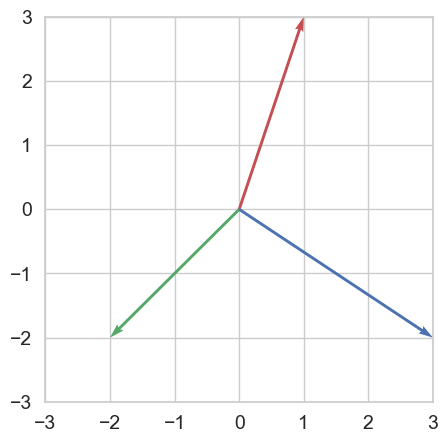

Given 
tensor([[ 1],
        [-2]])
The first column tensor([ 1, -2]) and the first row tensor([1])


In [7]:
plot2d(torch.tensor([[1,-2,3],[3,-2,-2]]))
plt.show()
print('Given \n{}\nThe first column {} and the first row {}'.format(t, t[:,0], t[0,:]))

- **Matrix transpose** - mirroring the matrix across the *main diagonal* - elements $A_{i,i}$
  - Every row becomes a column and vice verse $(\mathbf{A}^\top)_{i,j} = A_{j,i}$
  $$\mathbf{A} = \begin{bmatrix} A_{1,1} & A_{1,2} \\ A_{2,1} & A_{2,2}  \\  A_{3,1} & A_{3,2}\end{bmatrix} \Rightarrow \mathbf{A}^\top = \begin{bmatrix} A_{1,1} & A_{2,1} & A_{3,1} \\ A_{1,2} & A_{2,2} & A_{3,2}\end{bmatrix} $$
  - Main diagonal $\{A_{1,1}, A_{2,2}\}$
  

- **Matrix addition** - matrices $\mathbf{A}_{m,n}$ and $\mathbf{B}_{m,n}$ of the same shape $(m,n)$ can be added to each other $\mathbf{C}=\mathbf{A}+\mathbf{B}$, where $C_{i,j} = A_{i,j} + B_{i,j}$
  - If all rows of a matrix are equal $\mathbf{B}_{i,:}=\mathbf{b}$ then in DL a short notation might be used $\mathbf{C}=\mathbf{A}+\mathbf{b}$ which means $C_{i,j} = A_{i,j} + b_{j}$
  - The process of copying $\mathbf{b}$ to obtain $\mathbf{B}$ is called *broadcasting* 
- We can multiply matrices by a scalar or add a scalar to it $\mathbf{C}=a\mathbf{B}+d$, where $C_{i,j}=aB_{i,j}+d$

- **Matrix multiplication** is defined as
$$\mathbf{C} = \mathbf{A}\mathbf{B}$$
where
  - $\mathbf{A}$ must have the same number of columns $n$ as the number of rows in $\mathbf{B}$, i.e., $\mathbf{A}_{m,n}$ and $\mathbf{B}_{n,p}$
  - **matrix product** $\mathbf{C}$ is of the shape $(m,p)$
  $$ C_{i,j} = \sum_k A_{i,k}B_{k,j}$$
- Computation of matrix products is the central operation of DL
  - The best known algorithm of Le Gall (2014) has an asymptotic complexity is $O(n^{2.3728639})$, which is a generalization of the Coppersmith–Winograd algorithm (1990) with $O(n^{2.375477})$
  - It is worth fighting for $0.0026131$ in the exponent if you train networks with more than [$160\cdot 10^9$ parameters](https://spectrum.ieee.org/tech-talk/computing/software/biggest-neural-network-ever-pushes-ai-deep-learning) which might be updated any time a new portion of data is provided to a training algorithm
  - Can significantly be sped up by GPU's parallel processing possibilities

- **Properties** of matrix multiplication (see Peterson and Pederson for a much comprehensive list)
  - Distributivity $\mathbf{A}(\mathbf{B}+\mathbf{C})=\mathbf{A}\mathbf{B}+\mathbf{A}\mathbf{C}$
  - Associativity $\mathbf{A}(\mathbf{B}\mathbf{C})=(\mathbf{A}\mathbf{B})\mathbf{C}$
  - Not commutative $\mathbf{A}\mathbf{B}\neq\mathbf{B}\mathbf{A}$
  - Transpose of a matrix product $(\mathbf{A}\mathbf{B})^\top = \mathbf{B}^\top\mathbf{A}^\top$

In [8]:
# multiplication of a vector by a matrix allows us to scale and rotate it
# more transformation matrices can be found in Wikipedia
def rotate(v, alpha=90):
    a = math.radians(alpha)
    m = torch.tensor([[math.cos(a),-math.sin(a)],[math.sin(a), math.cos(a)]])
    r = torch.matmul(m,v)
    plot2d(torch.cat((r,v),1))
interactive(rotate, v=fixed(torch.tensor([[1],[0]], dtype=torch.float32)), alpha=(0,360,10))

interactive(children=(IntSlider(value=90, description='alpha', max=360, step=10), Output()), _dom_classes=('wi…

- **Trace of a matrix** $\mathbf{A}$ is defined as $\mathit{Tr}(\mathbf{A})=\sum_i A_{i,i}$
  - Trace is invariant to transpose $\mathit{Tr}(\mathbf{A})=\mathit{Tr}(\mathbf{A}^\top)$
  - Trace of a scalar $\mathit{Tr}(a)=a$
  - **Frobenius norm** an equivalent of $L_2$-vector norm for matrices is defined as 
  $$\lVert \mathbf{A} \rVert_F = \sqrt{\mathit{Tr}(\mathbf{A}\mathbf{A}^\top)}$$
  - $\mathit{Tr}(\mathbf{AB})=\mathit{Tr}(\mathbf{BA})$ and $\mathit{Tr}(\mathbf{A}+\mathbf{B})=\mathit{Tr}(\mathbf{A})+\mathit{Tr}(\mathbf{B})$ if involved matrices are of appropriate shapes

## Tensors

- Tensor is a generalization of a matrix, which corresponds to an array with more than 2 dimensions
  - The concept arose from the works of Carl Gauss in differential geometry
  - Originally, the concept "tensor" used by William Hamilton denoted something completely different 
  - Development of tensor calculus by Ricci-Curbastro around 1900
  - Became very popular since 1915 when Einstein formulated the general relativity theory using tensor analysis
- The definitions made so far do not work for tensors, but in DL these are mostly used to store and manipulate the wights of a network
- Elements of a tensor $\mathrm{A}$ are often referred using the same "coordinate" notation as in matrices, e.g., $A_{i,j,k}$

## Solving equations

- The most straight-forward application of linear algebra is solving systems of linear equations
$$\mathbf{Ax}=\mathbf{b}$$
where 
  - $\mathbf{A} \in \mathbb{R}^{m\times n}$ is a known matrix of coefficients,
  - $\mathbf{x} \in \mathbb{R}^{n\times 1}$ is a vector of variables, and
  - $\mathbf{b} \in \mathbb{R}^{m\times 1}$ is a known vector comprising the right sides
- To solve this system we need to find an inverse matrix $\mathbf{A}^{-1}$ of the matrix  $\mathbf{A}$ such that
$$\mathbf{A}^{-1}\mathbf{A}=\mathbf{I}_n$$
where $\mathbf{I}_n \in \mathbb{R}^{n\times n}$ is an **identity matrix** in which every $\mathbf{I}_{i,i} = 1$ and all other elements are $0$

- $\mathbf{Ax}$ is a **linear combination** of the columns of $\mathbf{A}$
  - If $\mathbf{x} \in \mathbb{R}^2$ then $\mathbf{Ax}$ defines the **column space** of $\mathbf{A}$ - in this case a 2D plane
  - Vector $\mathbf{b}$ is in the column space of $\mathbf{A}$ *iff* $\mathbf{Ax}=\mathbf{b}$ has a solution $(x_1,x_2)$
  - This is possible if vectors $A_{:,i} \in \mathbf{A}$ are linearly independent, i.e., cannot be represented as a linear combination of other columns
  - The **nullspace** contains all solutions $\mathbf{x}$ to $\mathbf{Ax}=\mathbf{0}$

- If $\mathbf{A}^{-1}$ exists then finding the solution is straightforward
$$\begin{split}
\mathbf{A}^{-1}\mathbf{Ax}=\mathbf{A}^{-1}\mathbf{b} \\
\mathbf{I}_n\mathbf{x}=\mathbf{A}^{-1}\mathbf{b} \\
\mathbf{x}=\mathbf{A}^{-1}\mathbf{b}
\end{split}$$

### Example

Consider a system of equations:
$$\begin{split}
3x_1+2x_2 = 5\\
-2x_1+2x_2 = 4
\end{split}$$
or in matrix form
$$\begin{bmatrix} 3 & 2 \\ -2 & 2 \end{bmatrix}\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 5 \\ 4 \end{bmatrix} $$

In [9]:
A = torch.tensor([[3,2],[-2,2]], dtype=torch.float32)
b = torch.tensor([[5],[4]], dtype=torch.float32)
x = torch.matmul(A.inverse(),b)
print("Found solution:\n {}".format(x))

Found solution:
 tensor([[0.2000],
        [2.2000]])


## Matrix decompositions

- Matrices might have various functional properties
- For instance, a vector can be rotated, scaled, sheared, etc., when multiplied by a matrix

tensor([[ 2.,  2.],
        [-4.,  8.]])
Plotting tensor with dim: 2 and shape: torch.Size([2, 2])


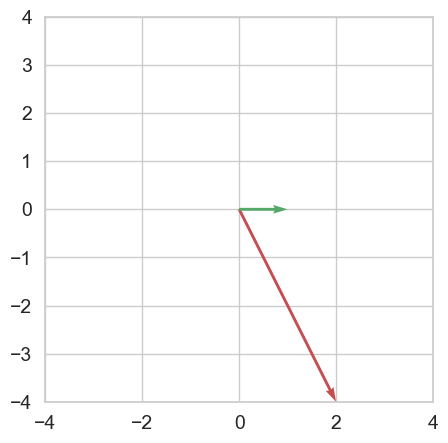

In [10]:
v = torch.tensor([[1],[0]], dtype=torch.float32)
m = torch.tensor([[2,2],[-4, 8]], dtype=torch.float32)
print(m)
plot2d(torch.cat((torch.matmul(m,v),v),1))

- However, there are vectors which directions do not change when multiplied by this matrix
- For example, consider the two vectors 

Input matrix:
 tensor([[ 2.,  2.],
        [-4.,  8.]])
Eigenvectors:
 tensor([[-0.7071, -0.4472],
        [-0.7071, -0.8944]])
Plotting tensor with dim: 2 and shape: torch.Size([2, 2])


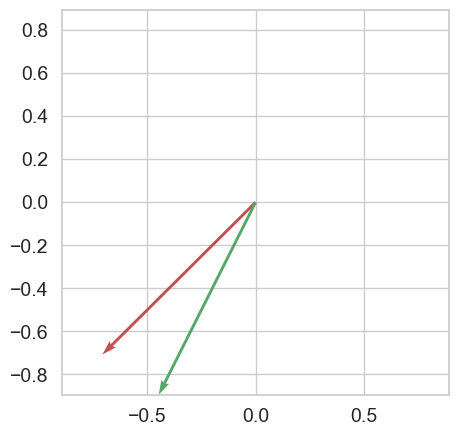

In [11]:
lm, ev = torch.linalg.eig(m)
print('Input matrix:\n', m)
print('Eigenvectors:\n', ev.real)
plot2d(ev.real)

- These vectors are only scaled when multiplied by the matrix

In [12]:
@interact(id=(0,1,1))
def plot_ev(id=0):
    v = ev[:,id].real.reshape(-1,1)
    plot2d(torch.cat((torch.matmul(m,v),v),1))

interactive(children=(IntSlider(value=0, description='id', max=1), Output()), _dom_classes=('widget-interact',…

### Eigendecomposition

- **Eigenvector** of a square matrix $\mathbf{A}$  is a non-zero vector $\mathbf{v}$ such that $$\mathbf{Av}=\lambda\mathbf{v}$$
where $\lambda$ is the corresponding **eigenvalue**
- We are looking only for unit eigenvectors, since if $\mathbf{v}$  is an eigenvector of $\mathbf{A}$, then so is $s\mathbf{v}$, where $s$ is a scalar
- **Eigendecomposition** of $\mathbf{A}$ is defined by
$$\mathbf{A} =\mathbf{V}\mathbf{\Lambda}\mathbf{V}^{-1}$$
where $\mathbf{V}$ is a set of all eigenvectors and $\mathbf{\Lambda} = \mathit{diag}(\mathbf{\lambda})$ is a diagonal matrix with eigenvalues $\mathbf{\lambda}$ on its main diagonal
- Decomposition of some matrices results in *complex* rather than *real* eigenvectors and eigenvalues

- Special case often met in ML - eigendecomposition of **real symmetric matrices**, i.e., $\mathbf{A} = \mathbf{A}^\top$
  - Eigenvectors are orthogonal - matrix $\mathbf{Q}$ comprising eigenvectors is orthogonal
  - Eigenvectors $\mathbf{Q}$ and eigenvalues $\mathbf{\Lambda}$ are real-valued
 $$\mathbf{A} =\mathbf{Q}\mathbf{\Lambda}\mathbf{Q}^{-1}$$

Symmetric matrix:
tensor([[17., 10.],
        [10., 13.]])
Plotting tensor with dim: 2 and shape: torch.Size([2, 2])


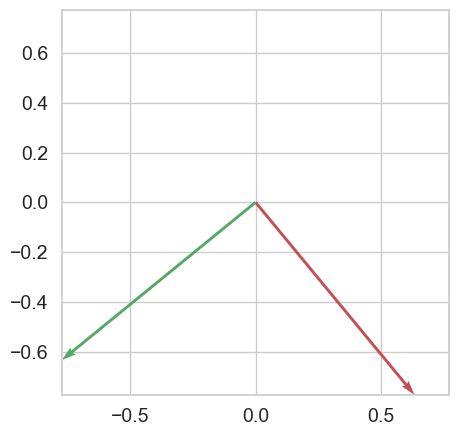

In [13]:
m = torch.tensor([[1,4],[-2, 3]], dtype=torch.float32)
m = torch.matmul(m,m.t())
print("Symmetric matrix:\n{}".format(m))
lm, ev = torch.linalg.eigh(m, UPLO='U')
plot2d(ev)

Plotting tensor with dim: 2 and shape: torch.Size([2, 2])


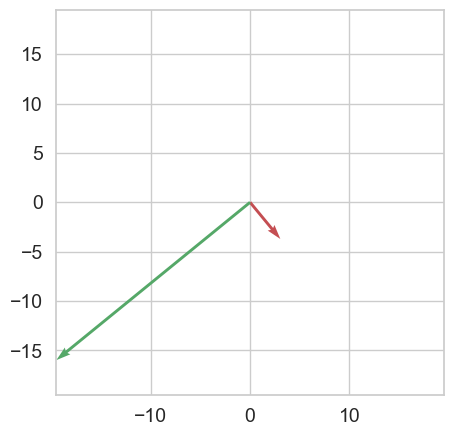

In [14]:
# eigenvectors scaled by eigenvalues 
plot2d(torch.matmul(ev, torch.diag(lm)))

## Computation of eigenvalues

- **Determinant** $\det\vec(A)$ is a function that maps a matrix to a real value
$$\det\vec(A) = \prod_i\lambda_i$$
where $\lambda_i$ for $i=1,\dots,n$ are *eigenvalues* of $\vec{A}$
- Geometrically, determinant can be interpreted as a measure how much a matrix expands/contracts a vectors if multiplied by it
  - if $\det\mathbf(A)=0$ then all vectors are contracted completely along at least one dimension $\Rightarrow$ the space looses its volume 
  - if $\det\mathbf(A)=1$ then the transformation preserves the volume 
- Determinants can be used to find eigenvalues
$$\vec{A}\vec{v}=\lambda\vec{v} \Rightarrow (\vec{A}-\lambda\vec{I})\vec{v} = 0$$
since eigenvectors cannot be zero, then $\vec{A}-\lambda\vec{I}$ is *singular* (not invertible) and $\det{(\vec{A}-\lambda\vec{I})}=0$
- If $\vec{A}$ is a $2\times 2$ matrix, then
$$\begin{vmatrix}a-\lambda&b\\c&d-\lambda\end{vmatrix}=\lambda^2-(a+d)\lambda+(ad-bc)=0$$
- For matrices of higher dimensions the number of root will be higher

### Singular value decomposition (SVD)

- Eigendecomposition is has a number of limitations: square matrices, complex eigenvalues, and computation complexity
- SVD is another decomposition that is very often used in practice
$$\vec{A} = \vec{U}\vec{D}\vec{V}^\top$$
 - $\vec{A}$ is a $m\times n$ matrix
 - $\vec{U}$ is a $m\times m$ orthogonal matrix of *left singular vectors*
 - $\vec{D}$ is a $m\times n$ diagonal matrix of *singular values*
 - $\vec{V}$ is a $n\times n$ orthogonal matrix of *right singular vectors* 

### Relation to the eigendecomposition

- $\vec{U}$ are the eigenvectors of $\vec{A}\vec{A}^\top$
- $\vec{V}$ are the eigenvectors of $\vec{A}^\top\vec{A}$
- Non-zero elements of $\vec{D}$ are the squared eigenvalues of $\vec{A}\vec{A}^\top$

<div class="myalert">Let us exemplify the theory presented above on a practical dimensionality reduction method</div>

# Principal Components Analysis (PCA)
+ Assume you face a dataset with a large set of correlated features
+ PCA allows us to summarize this set with a smaller number of "synthetic" features that collectively explain most of the variance in the original dataset
+ Given a dataset with $n$ observations of $p$ features

## Example: US arrests

+ Consider a data set containing statistics for each of the 50 US states in 1973:
    - arrests per 100,000 residents for assault, murder, and rape;
    - percent of the population living in urban areas

In [15]:
us = pd.read_csv('data/USArrests.csv')
states = us.pop(us.columns[0])
us.head()

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


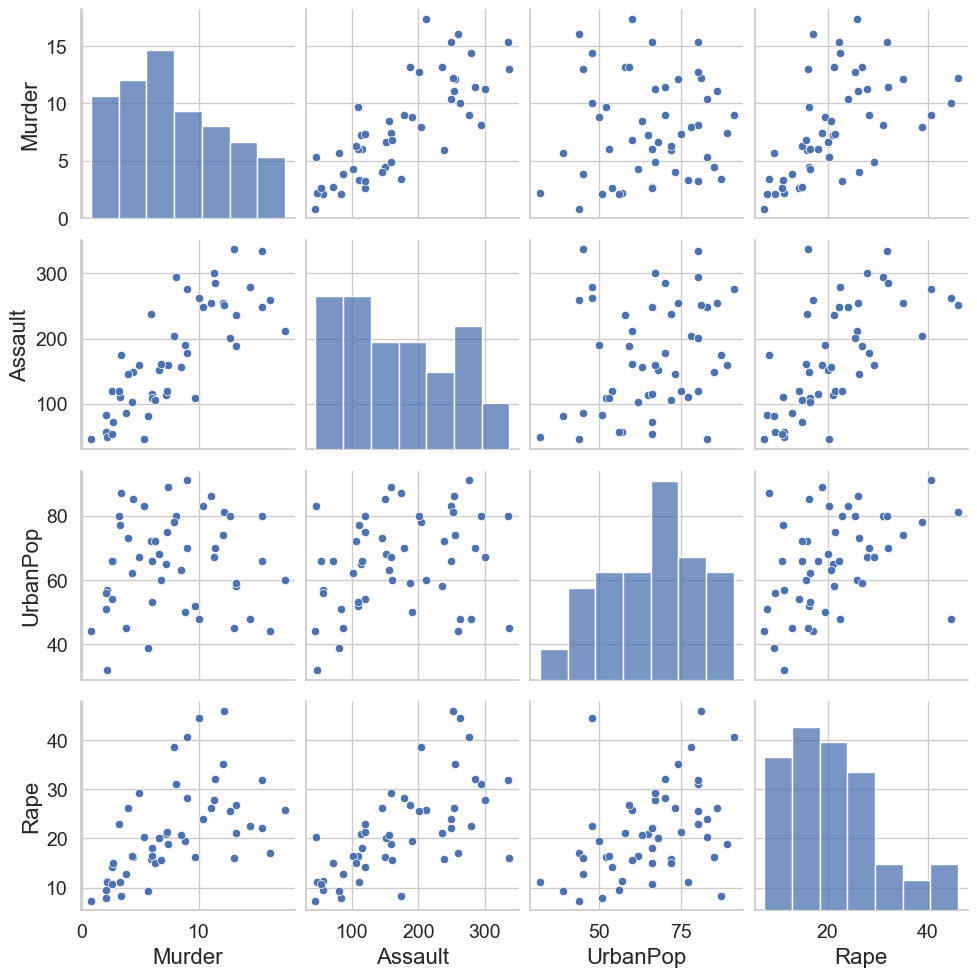

In [16]:
sns.pairplot(us);

In [17]:
us.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


## Standardization
+ Since we are only interested in variance it is recommended to rescale each feature vector
\begin{equation*}
x_{ij}'=\frac{x_{ij}-\mu_i}{\sigma_i}
\end{equation*}
where 
    - $x_{ji}$ is an observed value, 
    - $\mu_i$ is the mean of the population, can be estimated using the average $\overline{x}_i$ of all values observed for the feature $i$
    - $\sigma_i$ is the standard deviation of the population, can be estimated as $$S_i=\sqrt{\frac{1}{n-1}\sum{(x_{ji}-\overline{x}_i})^2}$$
    
+ Replacement of feature values with standard scores $x_{ij}'$ is called *standartization* and is recommended for many ML algorithms
+ The matrix of standard scores 
  - is *centered* - subtraction of the mean of every column from its values, and
  - has *unit standard deviation* - division by the standard deviation of the data in this column

In [18]:
# Application of the standard scaler to the first two columns 
# (for simplicity)
T_us = torch.tensor(us.values, dtype=torch.float32)
X_us = standardize(T_us)[:,[0,1]]
df_us = pd.DataFrame(data=X_us.numpy(), columns=us.columns[[0,1]])
df_us.describe()

,Murder,Assault
count,5.000000e+01,5.000000e+01
mean,-1.412630e-07,7.584691e-08
std,1.000000e+00,1.000000e+00
min,-1.604405e+00,-1.509042e+00
25%,-8.524836e-01,-7.410814e-01
50%,-1.235218e-01,-1.411126e-01
75%,7.948552e-01,9.388313e-01
max,2.206860e+00,1.994776e+00


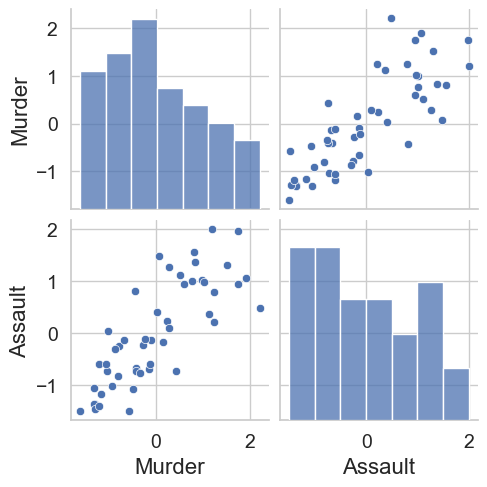

In [19]:
sns.pairplot(df_us);

In [20]:
interact(plot_scores, x=fixed(1), y=(-1,1,0.2));

interactive(children=(FloatSlider(value=0.0, description='y', max=1.0, min=-1.0, step=0.2), Output()), _dom_cl…

## Principal Components

+ Given an $n \times p$ matrix $\vec{X}$ of observations of $p$ random variables
+ Principal component $\vec{z}_i$ is a normalized linear combination, where last condition is the normalization requirement

\begin{equation*}
\vec{z}_i=\phi_{1i}\vec{x}_1+\dots+\phi_{pi}\vec{x}_p \text{ such that } \sum_{1\leq j \leq p} \phi_{ji}^2=1
\end{equation*}

+ Vector $\vec{\phi}_i=[\phi_{1i},\dots,\phi_{pi}]^\top$ is called a *principal direction* or *axis* of a principal component $\vec{z}_i$
+ Geometrically, the axis $\vec{\phi}_1$ of the first component $\vec{z}_1$ defines a direction in which the data vary the most, and so on
+ Normalization constraint is required, since otherwise these values can be arbitrary large
+ Values $z_{1i}, \dots, z_{ni} \in \vec{z}_i$ are called *scores* of the principal component $\vec{z}_i$

## Computation

+ *Goal*: find a sequence of principal components that have **maximal variance** and are **mutually uncorrelated**
+ Computation of the first principal component corresponds to the optimization problem
\begin{equation*}
\max_{\phi_{11},\dots,\phi_{p1}} \frac{1}{n}\sum_{i=1}^n{z_{i1}^2} \text{ subject to } \sum_{1\leq j \leq p} \phi_{j1}^2=1
\end{equation*}
where $z_{i1}=\phi_{1i}x_1+\dots+\phi_{pi}x_p$
    + That is, we maximize the sample variance of the scores $z_{i1}$ for $1\leq i \leq n$ 
    + This optimization problem is usually solved using the *singular value decomposition* of the matrix $\vec{X}$ 

### Computation details

+ The PCA optimization problem is solved using the eigenvector decomposition of the covariance matrix $\vec{C}$ defined as $$\vec{C}=\frac{\vec{X}^\top\vec{X}}{(n-1)}$$ where $\vec{X}$ is a *centered* $n\times m$ matrix of observations
+ Eigenvalue decomposition of $\vec{C}=\vec{V}\vec{\Lambda}\vec{V}^\top$
   - $\vec{V}$ is a matrix of eigenvectors corresponding to principle directions (axes)
   - Projection of data on these axes $\vec{X}\vec{V}$ gives principal components (scores)
   - $\vec{\Lambda}$ indicate the amount of variance explained
+ Solution with SVD of $\vec{X}=\vec{U}\vec{D}\vec{V}^\top$
    $$ \vec{C} = \frac{1}{n-1}\vec{V}\vec{D}\vec{U}^\top \vec{U}\vec{D}\vec{V}^\top   = \vec{V}\frac{\vec{D}^2}{n-1}\vec{V}^\top$$
  + $\vec{U}^\top \vec{U} = \vec{I}$ because $\vec{U}$ is orthogonal by the definition of the decomposition
  + $\Rightarrow$ columns in $\vec{V}$ are principal directions (eigenvectors of the covariance matrix)
  + $\Rightarrow$ projection of data on these directions $\vec{X}\vec{V} = \vec{U}\vec{D}\vec{V}^\top\vec{V}=\vec{U}\vec{D}$ gives us the scores of the components
  + $\Rightarrow$ loadings - directions $\vec{V}$ scaled by square roots of eigenvalues $\vec{\Lambda}$ of the covariance matrix - are given by columns of 
  $${\vec{V}\frac{\vec{D}}{\sqrt{n-1}}} ~~~~\text{since} ~~~~\vec{\Lambda} = \frac{\vec{D}^2}{n-1}$$

## Example: US arrests (small)

+ Apply PCA to find the first two columns of the *standardized* US Arrests dataset 

In [21]:
def std_PCA(X, k=2):   
    n = X.size()[0]
    if (k>X.size()[1]): 
        raise ValueError('k must be smaller or equal to {}'.format(X.size()[1]))

    u,d,v = torch.svd(X)
    d = torch.diag(d)
    comps = v[:,:k].t()
    var_exp = torch.matmul(d,d)/(n-1)
    scores =  torch.matmul(u,d)[:,:k]
    loadings = torch.matmul(v, torch.sqrt(var_exp))
    return (scores, comps, torch.diag(var_exp)[:k], loadings[:k].t())

sc_s, cs_s, ve_s, l_s = std_PCA(X_us)
print("Direction of the first component: ({:.3f}, {:.3f})".format(cs_s[0,0], cs_s[0,1]))
print("Direction of the second component:  ({:.3f}, {:.3f})".format(cs_s[1,0], cs_s[1,1]))

Direction of the first component: (-0.707, -0.707)
Direction of the second component:  (0.707, -0.707)


+ The first principal axis $\phi_1=(-0.707,-0.707)$ defines a direction in the feature space along which the data varies most
\begin{equation*}
\vec{z}_1=-0.707\vec{m} + (-0.707)\vec{a}
\end{equation*}
+ The second axis - the second direction
\begin{equation*}
\vec{z}_1=0.707\vec{m} + (-0.707)\vec{a}
\end{equation*}

- Since we have $50$ observations, the score vectors $\vec{z}_1$ and $\vec{z}_2$ have also $50$ values
- The original data points and a principle direction are shown on the left
- Projections of the data points on the axis - on the right

In [22]:
@interact(i=(0,1))
def plot_dirs(i=0):
    plot_scores(cs_s[i,0], cs_s[i,1])

interactive(children=(IntSlider(value=0, description='i', max=1), Output()), _dom_classes=('widget-interact',)…

### Loading vectors

+ A *loading vector* is a principal direction scaled by the square root of the variance of the original variable it explains 
    + The green arrow shows the direction of the first component and the orange one -- of the second
    + Length of the vectors - proportion of the variance explained

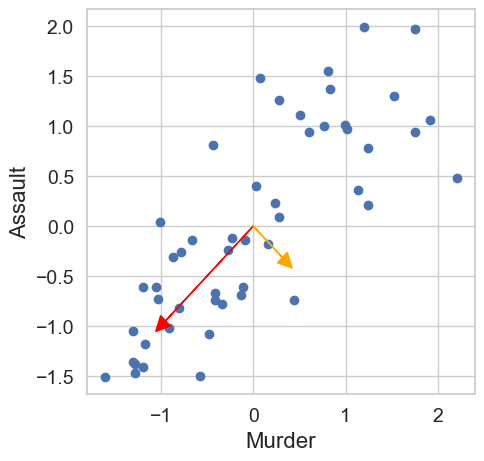

In [23]:
colors=['red', 'orange']
fig = plt.figure(figsize=(5,5))
plt.scatter(X_us[:,0],X_us[:,1])
plt.xlabel(us.columns[0])
plt.ylabel(us.columns[1])

for i in range(2):
    plt.arrow(0, 0, l_s[i,0], l_s[i,1], ec=colors[i],
              head_width=0.15, head_length=0.15, fc=colors[i])

## Example: US Arrests (full)

- All four components of the data set 

In [24]:
X_full = standardize(T_us)
sc_f, cs_f, ve_f, l_f = std_PCA(X_full, k=4)
print("Principal directions are given in the rows")
pd.DataFrame(data=cs_f.numpy(), columns=us.columns)

Principal directions are given in the rows


,Murder,Assault,UrbanPop,Rape
0,-0.535899,-0.583184,-0.278191,-0.543432
1,0.418181,0.187986,-0.872806,-0.167319
2,-0.341233,-0.268149,-0.378016,0.817778
3,0.649228,-0.743407,0.133878,0.089024


- Visualizing the impact of variables on each component can be done using heat maps

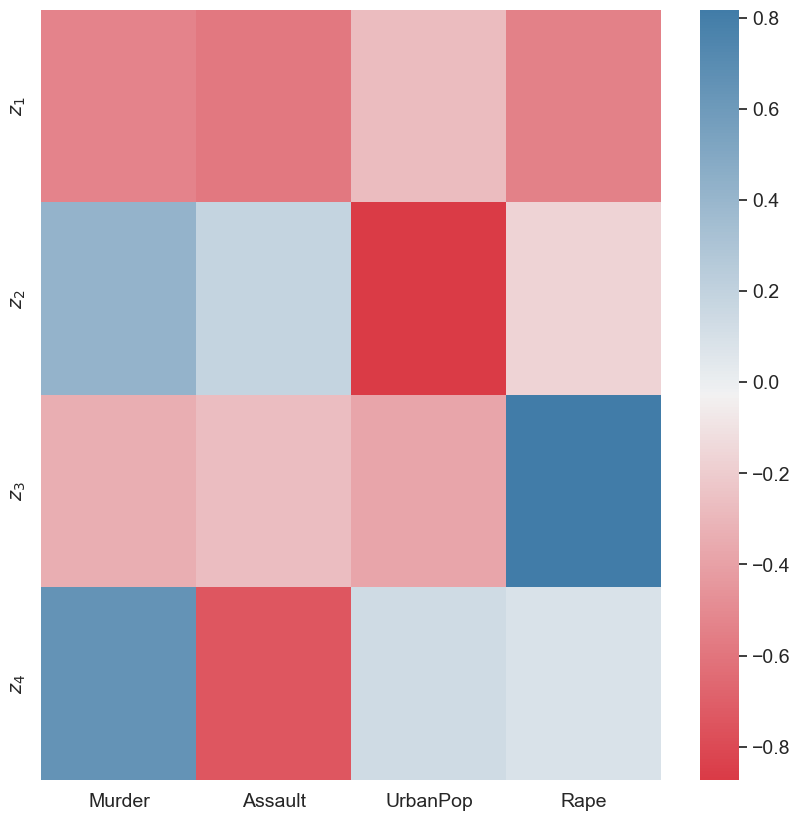

In [25]:
sns.heatmap(cs_f, cmap=sns.diverging_palette(10,240, as_cmap=True),
            yticklabels=["$z_"+str(x) + "$" for x in range(1,len(cs_f)+1)],
            xticklabels=list(us.columns));

- Variance explained by each component

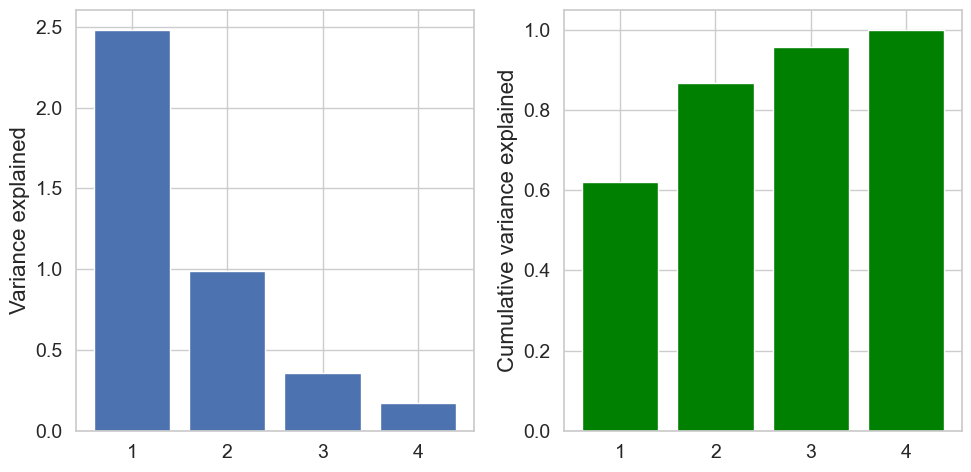

In [26]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True)
ax[0].bar(range(1,len(ve_f)+1), ve_f)
ax[0].set_ylabel('Variance explained')
ax[1].set_ylabel('Cumulative variance explained')
ax[1].bar(range(1,len(ve_f)+1), torch.cumsum(to_coefficients(ve_f), dim=0), color='green')
fig.tight_layout()

## Example: US Arrests (biplot)

+ Biplot shows both principal component scores and loadings

In [27]:
def biplot(z1, z2, sc, comps, obs, features, colors):
    x, y = sc[:,z1], sc[:,z2]
    
    fig = plt.figure(figsize=(10,10))
    plt.xlabel("$z_{}$".format(z1))
    plt.ylabel("$z_{}$".format(z2))

    sx = (x.max() - x.min())/2
    sy = (y.max() - y.min())/2

    plt.scatter(x,y)
    for i in range(len(obs)):
        plt.text(x[i], y[i], obs[i], ha='center', fontsize=12)

    vec = np.transpose(comps[[z1,z2], :])
    
    for i in range(len(vec)):
        plt.arrow(0, 0, vec[i,0]*sx, vec[i,1]*sy, ec=colors[i],
                  head_width=0.1, head_length=0.1, fc=colors[i])
        plt.text(vec[i,0]*sx*1.2, vec[i,1]*sy*1.2, features[i], 
                 color = colors[i])

    plt.grid()

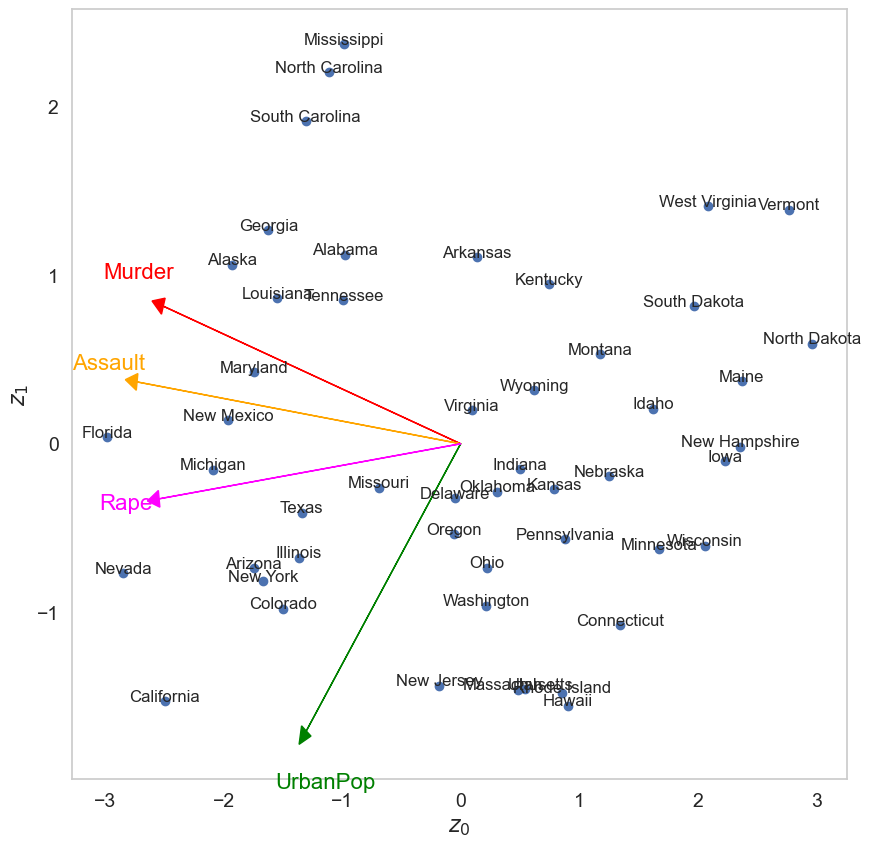

In [28]:
z1, z2 = 0, 1
biplot(z1, z2, sc_f, l_f, states, us.columns, colors=['red', 'orange', 'green', 'magenta'])

+ State names - scores for the first two principal components
+ Arrows - show loading vectors of the first two principal components (axes top and right)
+ First loading vector places appr. equal weight on *Assault*, *Murder* and *Rape* - roughly - measure of overall rates of serious crimes
    - Three "crime" variables are correlated - states with a high rate in one crime tend to have higher rates in other crimes
+ Second vector places most weight on *UrbanPop* and much less on other features
+ Score vectors:
    - California high urbanization and crime rate
    - Vermont low urbanization and low crime rate
    - Florida high crime rate and average urbanization

## Example: Iris

- Consider a data set containing measurement of 150 iris flowers:
    - 3 types of flowers: setosa, versicolor, and virginica
    - 4 features: width and length of sepal and petal leaves


<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/01_Introduction/images/iris.png" width="50%"/>
</center>

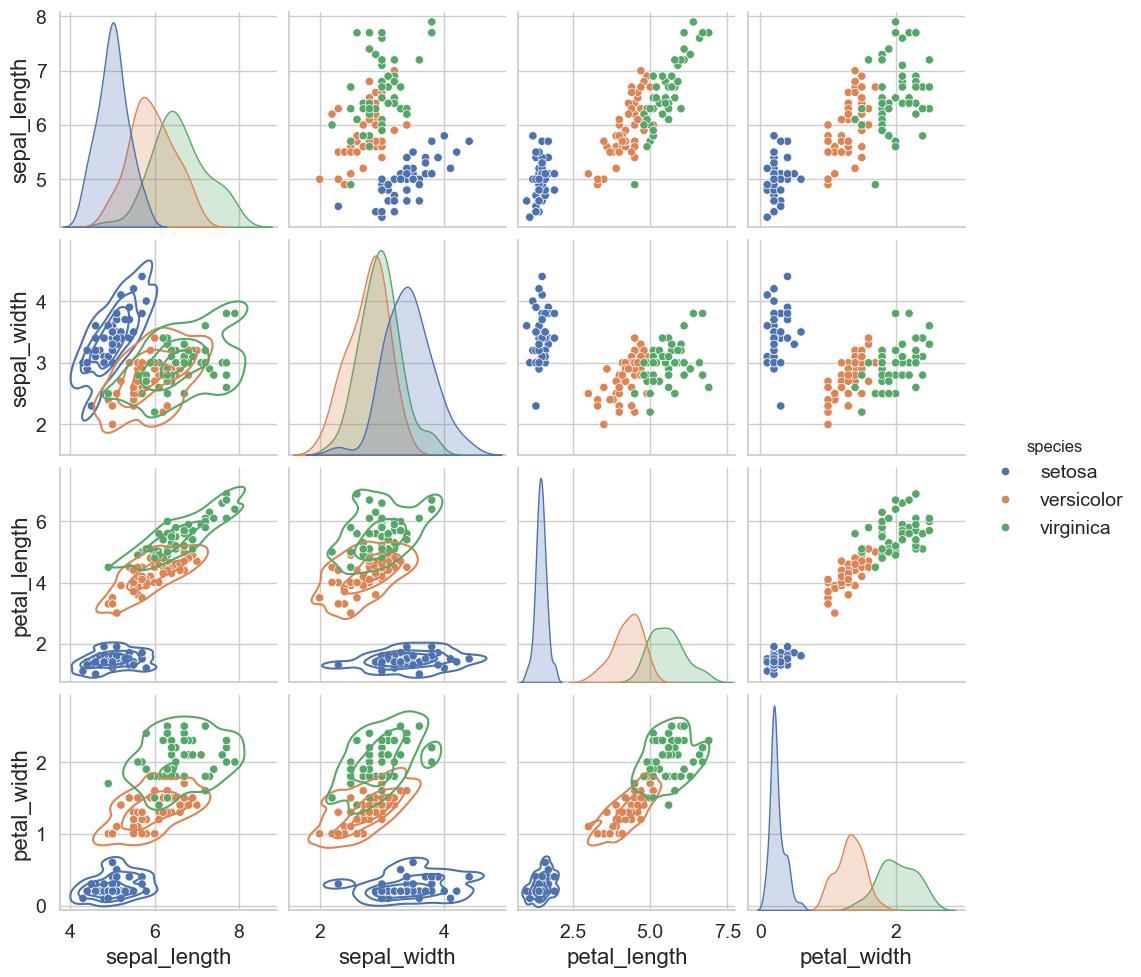

In [29]:
dfi = sns.load_dataset("iris")
fig = sns.pairplot(dfi, hue="species")
fig.map_lower(sns.kdeplot, levels=4, color=".2");

In [30]:
X_iris = standardize(torch.tensor(dfi.iloc[:,0:4].values, dtype=torch.float32))
sc_i, cs_i, ve_i, l_i = std_PCA(X_iris, k=4)
print("Principal directions are given in the rows")
pd.DataFrame(data=cs_i.numpy(), columns=us.columns)

Principal directions are given in the rows


,Murder,Assault,UrbanPop,Rape
0,0.521066,-0.269347,0.580413,0.564857
1,-0.377418,-0.923296,-0.024492,-0.066942
2,0.719566,-0.244382,-0.142126,-0.634273
3,0.261286,-0.123509,-0.801449,0.523597


- Biplot for the two first principal components of iris data set

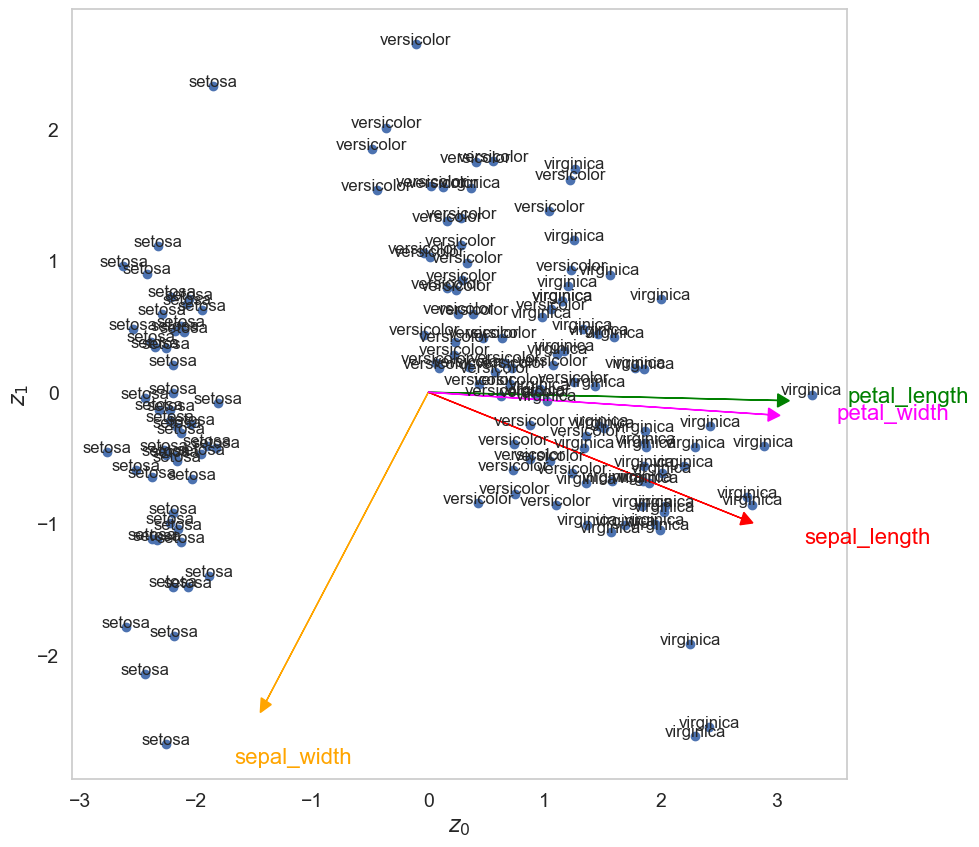

In [31]:
z1, z2 = 0, 1
biplot(z1, z2, sc_i, l_i, dfi["species"], dfi.columns, 
       colors=['red', 'orange', 'green', 'magenta'])

## Example: Image compression

+ Application of PCA to every of the three color channels of an image
+ The result shows an image obtained by using only 15 out of 320 principle components

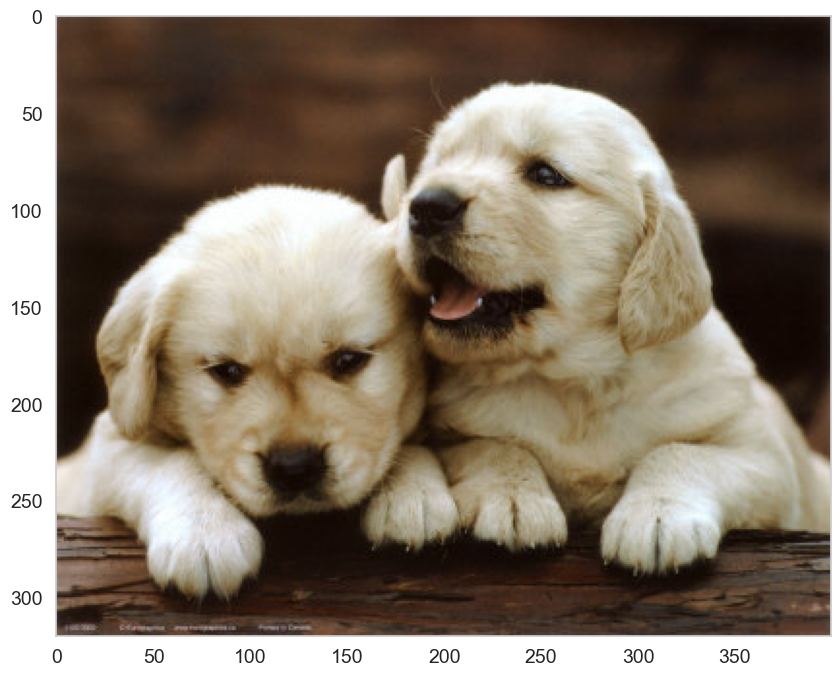

In [32]:
img = mpimg.imread('./images/puppy.jpeg')
plt.imshow(img)
plt.grid(None);

In [33]:
def extractComps(img, comps=30):
    out=[]
    fig, ax = plt.subplots(1, 3, sharex=True, figsize=(15,5))
    colors=['red', 'green', 'blue']
    for i in range(len(colors)):
        sc, cp, ve, l = std_PCA(img[:,:,i], k=comps)
        img_t = torch.matmul(sc, cp)
        print("{}: scores {} and components {}".format(colors[i], sc.shape, cp.shape))
        ax[i].bar(range(1,comps+1), to_coefficients(ve), color=colors[i])
        out.append(normalize(img_t))

    fig.tight_layout()
    return out

In [34]:
@interact(comps=(5,300,5), continious_update=False)
def compress(comps=15):
    fig, ax = plt.subplots(1,2, figsize=(10,15))
    ax[0].imshow(img)
    ax[0].grid(False)
    ax[1].imshow(torch.dstack(extractComps(torch.tensor(img, dtype=torch.float32), comps)))
    ax[1].grid(False)
    plt.show()

interactive(children=(IntSlider(value=15, description='comps', max=300, min=5, step=5), Output()), _dom_classe…